In [ ]:
#Step 1- Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
#step 2- load dataset
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
#step 3- understand the dataset
df.shape,df.info(),df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


((200, 5),
 None,
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
 count  200.000000  200.000000          200.000000              200.000000
 mean   100.500000   38.850000           60.560000               50.200000
 std     57.879185   13.969007           26.264721               25.823522
 min      1.000000   18.000000           15.000000                1.000000
 25%     50.750000   28.750000           41.500000               34.750000
 50%    100.500000   36.000000           61.500000               50.000000
 75%    150.250000   49.000000           78.000000               73.000000
 max    200.000000   70.000000          137.000000               99.000000)

In [ ]:
#step 4- check missing value and dupliactes
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df =df.drop_duplicates()

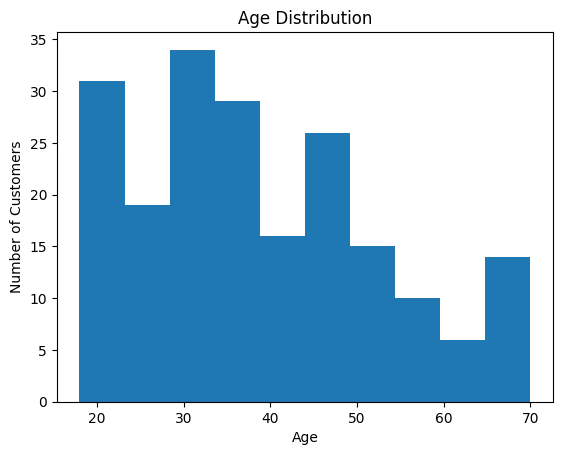

In [ ]:
#step 5-Exploratory data analysis
plt.hist(df['Age'],bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")
plt.show()

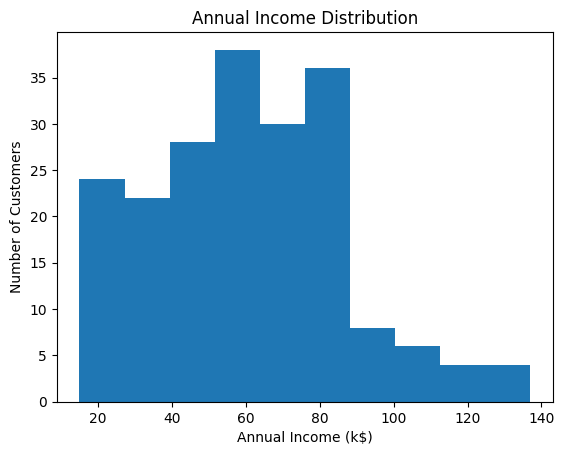

In [ ]:
plt.hist(df['Annual Income (k$)'],bins=10)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.title("Annual Income Distribution")
plt.show()

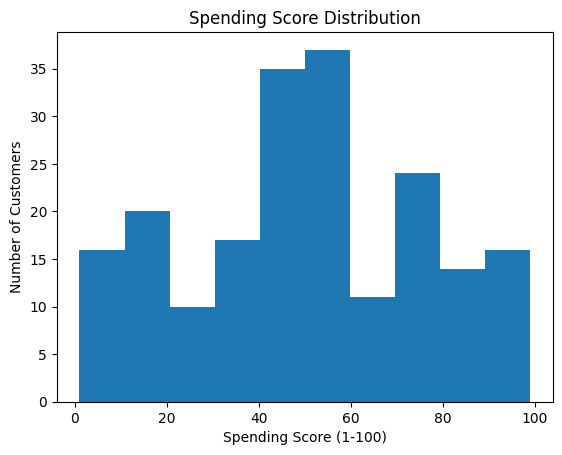

In [ ]:
plt.hist(df['Spending Score (1-100)'],bins=10)
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")
plt.title("Spending Score Distribution")
plt.show()

In [ ]:
#step 6 - Select features
x = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [ ]:
#step 7-Features Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

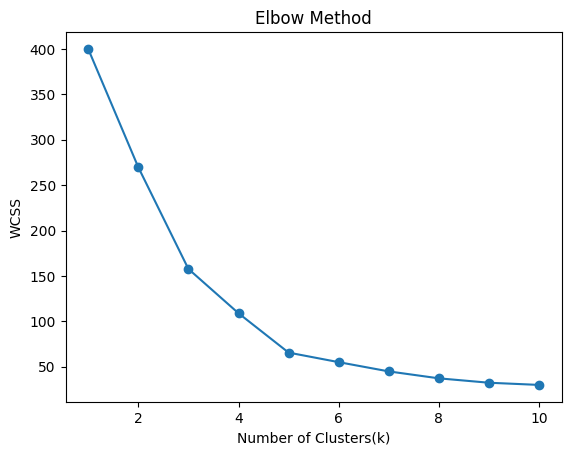

In [ ]:
#step 8 Elbow Method
WCSS = []
for k in range(1,11):
    model=KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(x_scaled)
    WCSS.append(model.inertia_)
plt.plot(range(1, 11), WCSS, marker="o")
plt.xlabel("Number of Clusters(k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
#step 9-Train Model
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
clusters = kmeans.fit_predict(x_scaled)

In [ ]:
#step 10- Add clusters Labels
df['Cluster'] = clusters
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


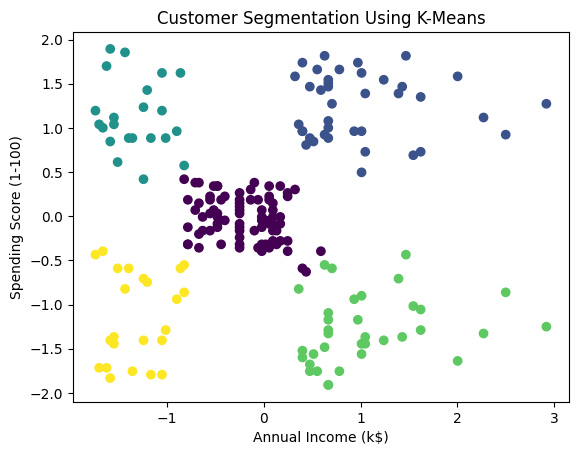

In [ ]:
#step 11-Visualize Clusters
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=clusters)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation Using K-Means")
plt.show()

In [ ]:
# step 12 Analyze Each Clusters
cluster_summary=df.groupby('Cluster')[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean
cluster_summary

<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x7856da378050>>

In [ ]:
#step 13-New Customer Segmentation
new_customer = np.array([[80,75]])
new_customer_scaled = scaler.transform(new_customer)
cluster = kmeans.predict(new_customer_scaled)
print("Customer belongs to cluster",cluster[0])


Customer belongs to cluster 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
